## essential libraries


In [27]:
import tensorflow as tf
from tensorflow. keras import models, layers 
import matplotlib.pyplot as plt


In [28]:
IMAGE_SIZE = 256
BATCH_SİZE = 32
CHANELLS = 3
EPOCHS = 10

In [29]:
dataset =tf.keras.preprocessing.image_dataset_from_directory(
    "training" ,
    shuffle = True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SİZE
)   

Found 2152 files belonging to 3 classes.


In [30]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [31]:
len(dataset) ## cuz we have 68 batches of data

68

In [32]:
68*32 ## 2176 images in total

2176

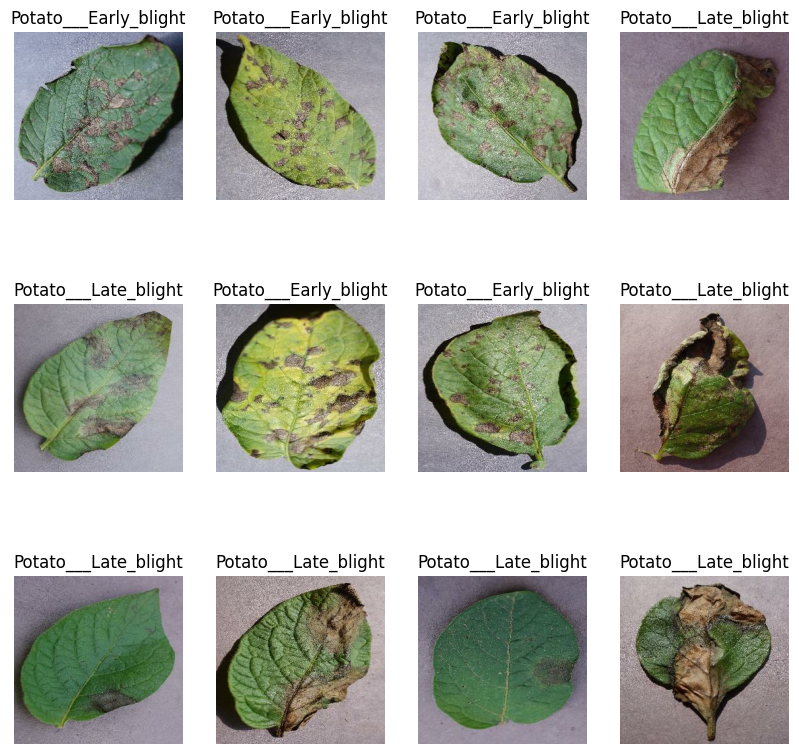

In [33]:
plt.figure(figsize=(10,10))

for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")



# we will use the following values 
80% training
 10% validation 
 10%test

In [34]:
len(dataset)
train_size = 0.8
len(dataset)*train_size 
train_ds = dataset.take(54)
len(train_ds)
remaining = dataset.skip(54)
len(remaining)
##this is the remaining 20% of the data for testing
val_size = 0.1
len(dataset)*val_size
val_ds = remaining.take(6)
len(val_ds)
test_ds = remaining.skip(6)
len(test_ds)

8

or we can just write a wel organized function for all above operations

In [35]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True,shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)


    return train_ds, val_ds, test_ds


In [36]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

we can boost the model by applying cache and prefetch methods

In [37]:
train_ds = train_ds.cache().shuffle (1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

if we train our model with external deta we need to rescale it as below:

In [39]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),  # Resize images to (Image_Size, Image_Size)
    layers.Rescaling(1.0/255)  # Rescale pixel values from [0, 255] to [0, 1]
])

also we can apply a data augmentation layer to boost the model with extra data

In [41]:
data_augmentation = tf.keras.Sequential([
layers.RandomFlip("horizontal_and_vertical"), 
layers.RandomRotation (0.2),
])